<a href="https://colab.research.google.com/github/davisbridg-projects/foodhub-python-analysis/blob/main/Copy_of_Davis_Bridgette_Python_FoodHub_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!jupyter nbconvert --to html /content/Davis_Bridgette_Python_FoodHub_Project.ipynb

[NbConvertApp] Converting notebook /content/Davis_Bridgette_Python_FoodHub_Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp] Writing 1515276 bytes to /content/Davis_Bridgette_Python_FoodHub_Project.html


In [ ]:
# read the data
df = pd.read_csv('/content/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### **Observations:** The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer. I noticed that in the rating columns, the first two values are not numerical.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape

(1898, 9)

#### **Observations:** In addition to knowing there are 9 columns, I am now aware this is a pretty sizable dataset with 1898 rows.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations:** The rating column has an object data type. Which may need to be modified later.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### **Observations:** There are no missing values.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### **Observations:** The **minimum** time it takes for food to be prepared once an order has been placed is 20 minutes. The **maximumn** time is 35 minutes and the **average** time is 27 minutes.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df['rating'].value_counts(normalize=False).astype(int)

,count
rating,
Not given,736
5,588
4,386
3,188


#### **Observations:** There are a total of 736 ratings that are missing/"not given".


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
plt.style.use('ggplot')

<Axes: xlabel='order_id', ylabel='count'>

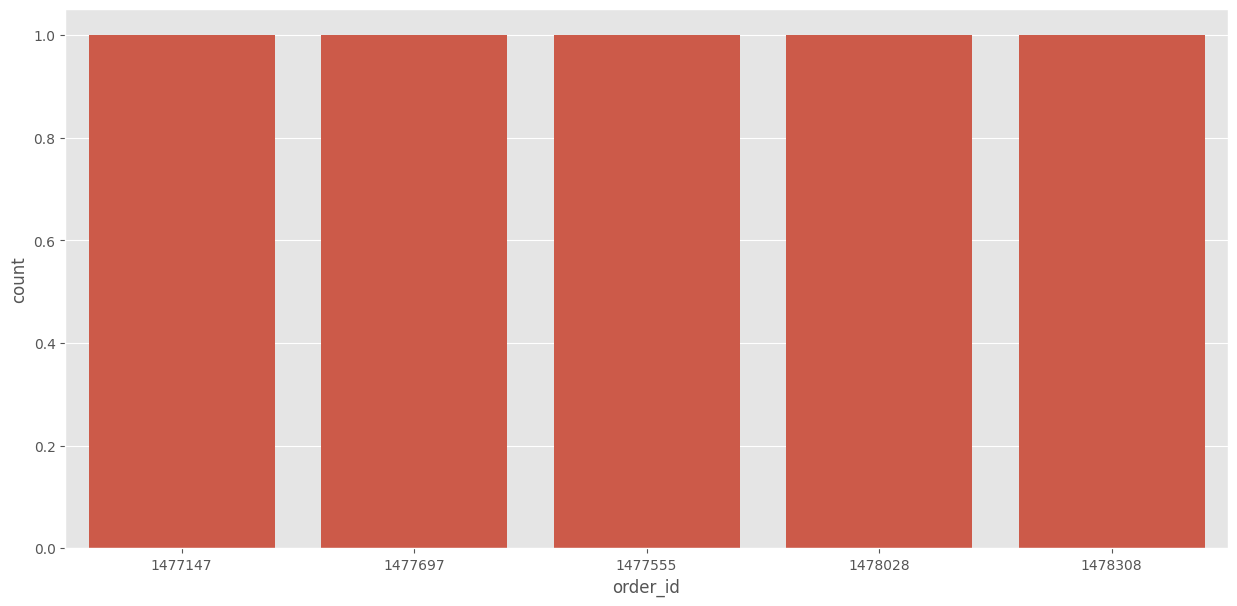

In [ ]:
#order_id
plt.figure(figsize =(15,7))
sns.countplot(data =df, x ="order_id", order =df['order_id'].value_counts().head().index)

<Axes: xlabel='customer_id', ylabel='count'>

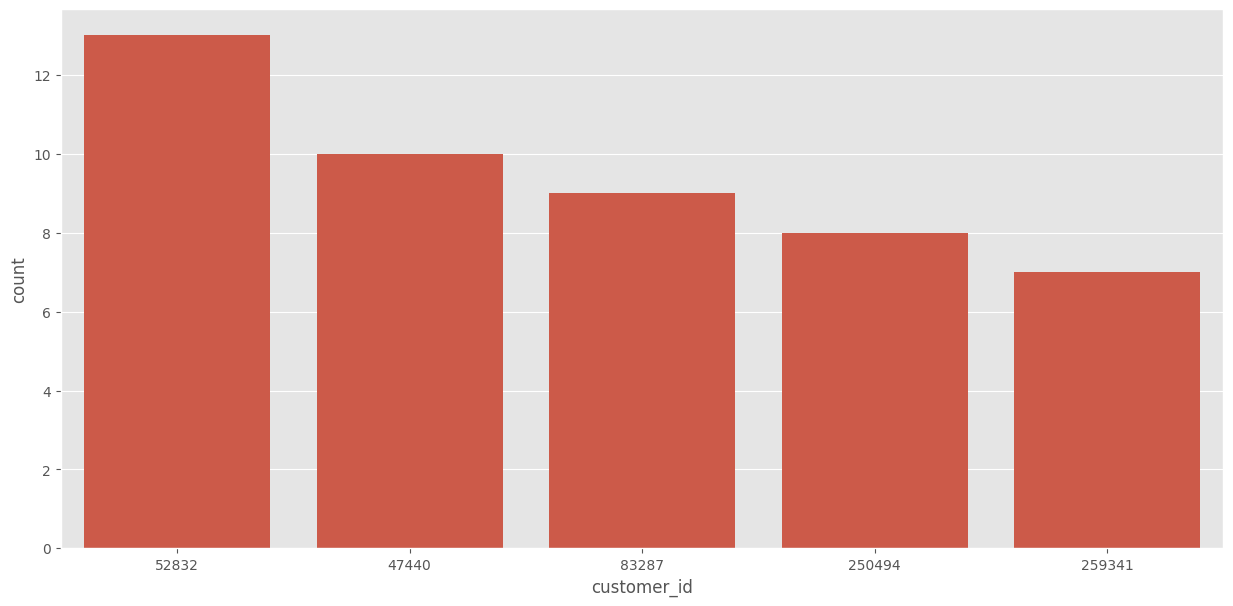

In [ ]:
#customer_id
plt.figure(figsize =(15,7))
sns.countplot(data =df, x ="customer_id", order =df['customer_id'].value_counts().head().index)

<Axes: xlabel='restaurant_name', ylabel='count'>

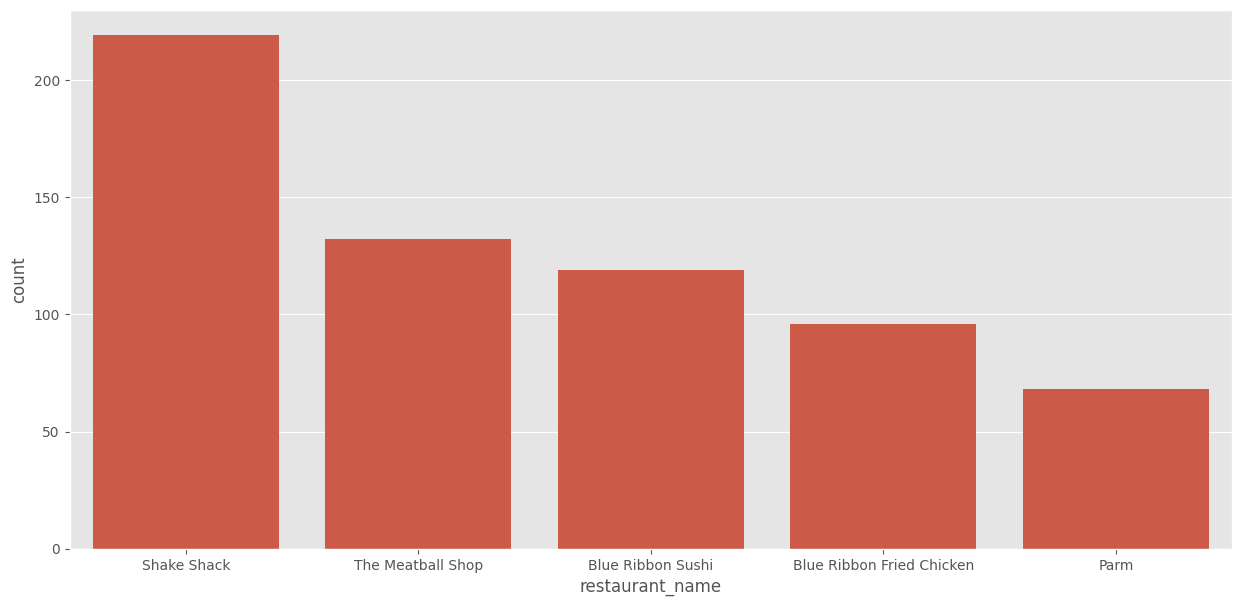

In [ ]:
#restaurant_name
plt.figure(figsize =(15,7))
sns.countplot(data =df, x ="restaurant_name", order =df['restaurant_name'].value_counts().head().index)

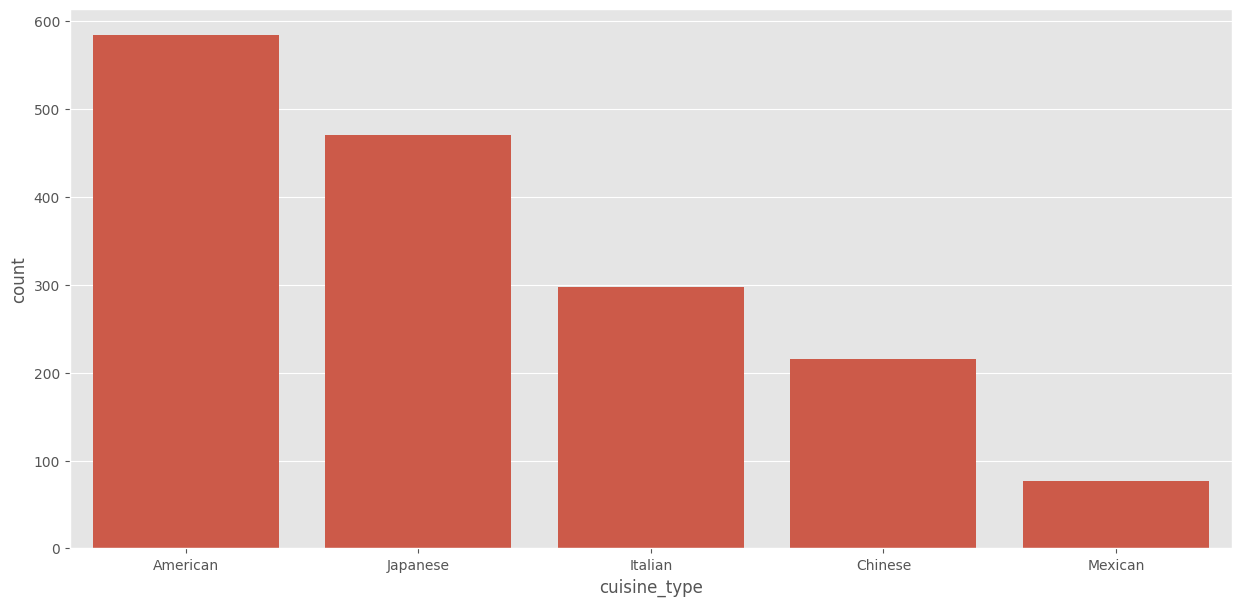

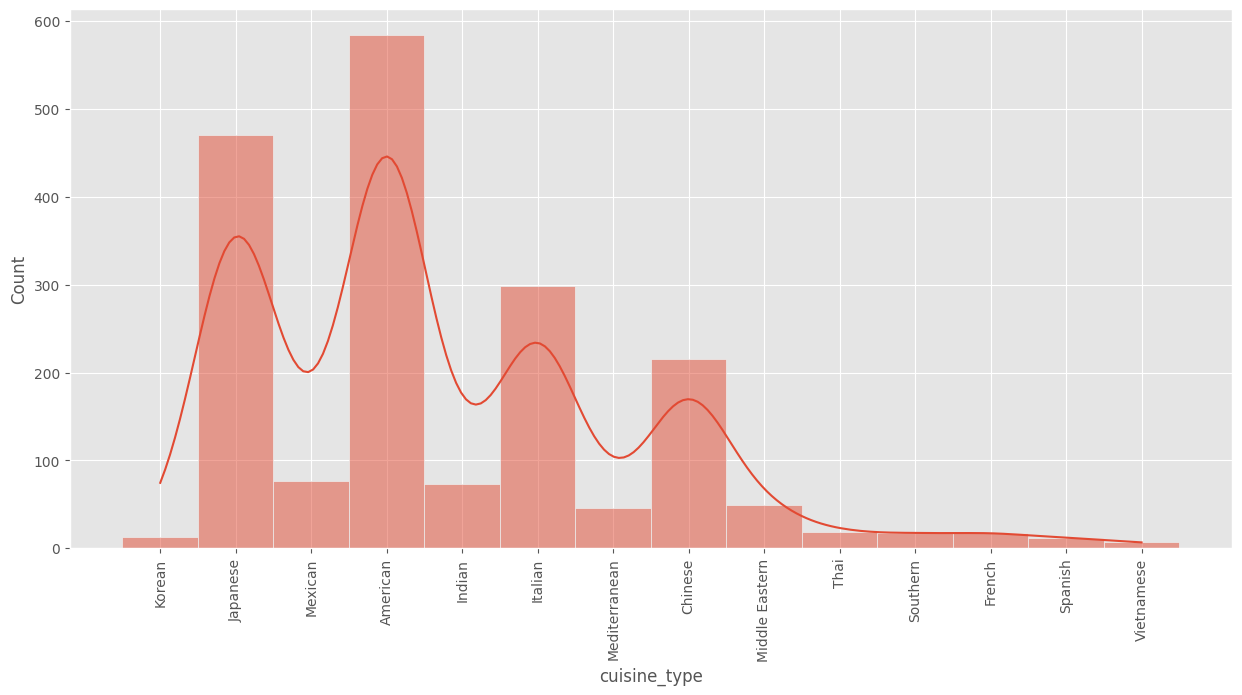

In [ ]:
#cuisine_type
plt.figure(figsize =(15,7))
sns.countplot(data =df, x ="cuisine_type", order =df['cuisine_type'].value_counts().head().index)
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ="cuisine_type", kde = True)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='cost_of_the_order'>

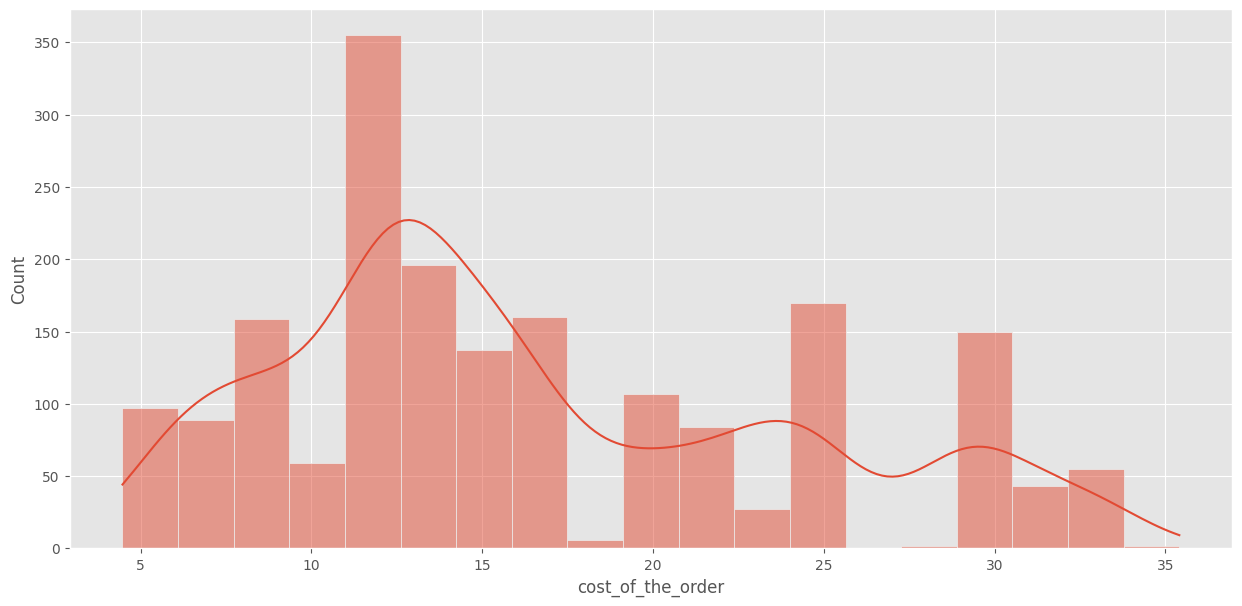

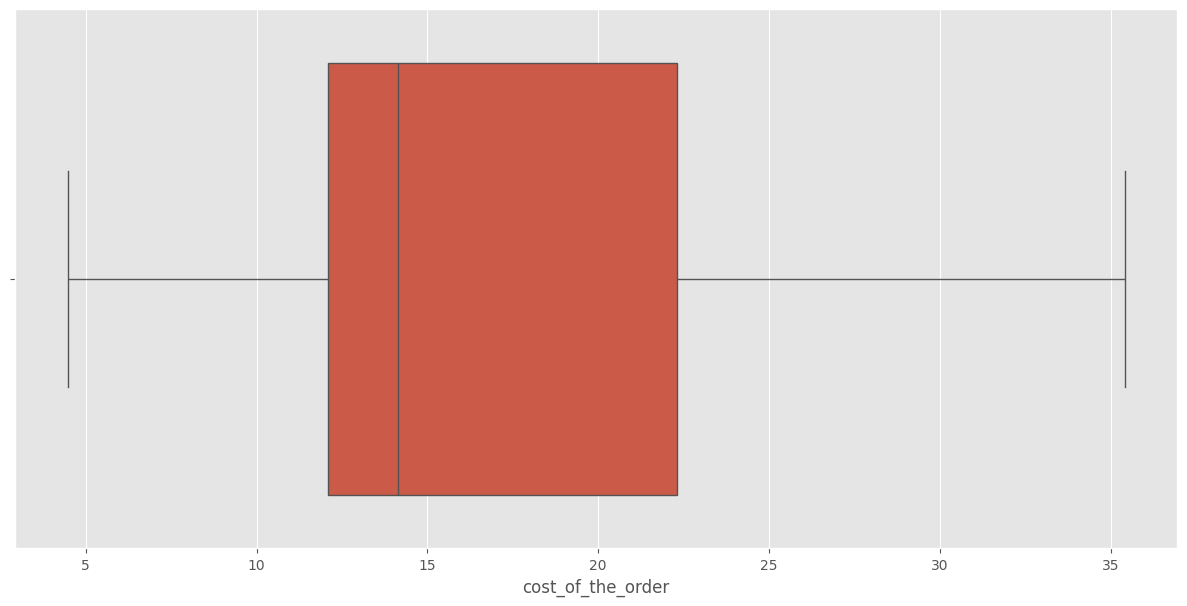

In [ ]:
#cost_of_the_order
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ="cost_of_the_order", kde = True)
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ="cost_of_the_order")

<Axes: xlabel='rating', ylabel='Count'>

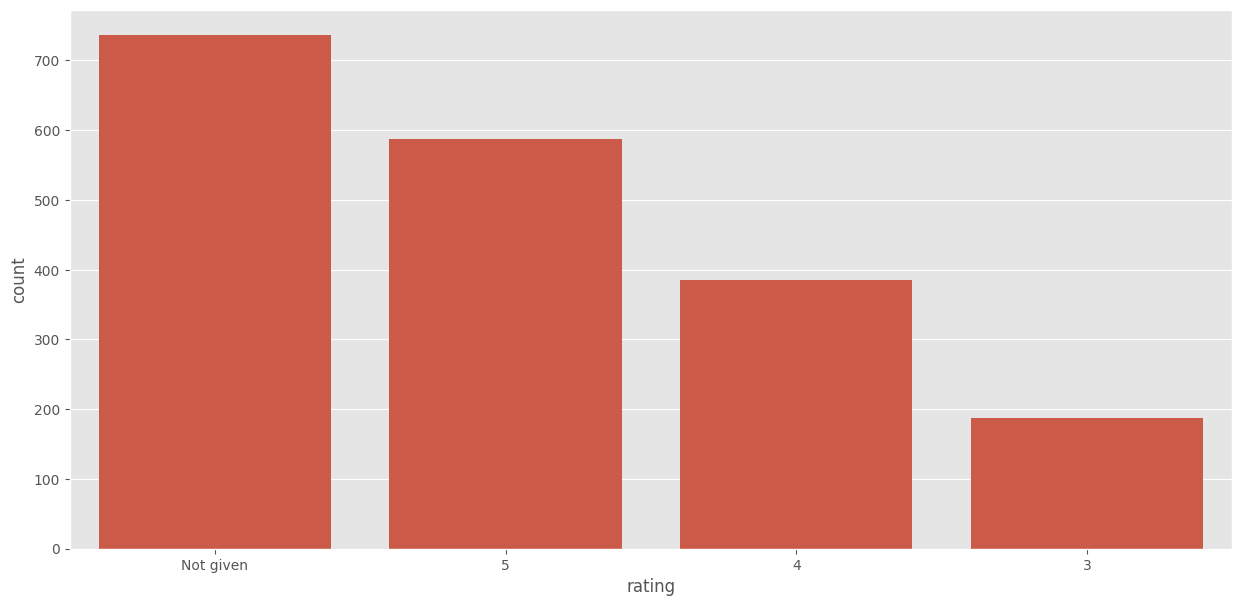

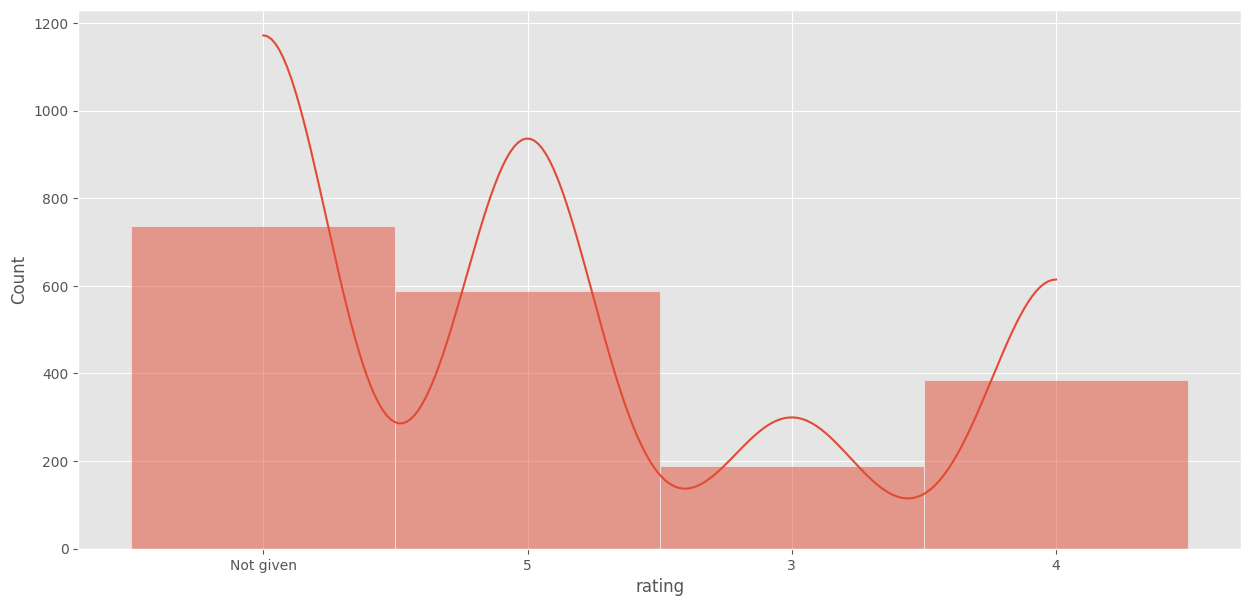

In [ ]:
#rating
plt.figure(figsize =(15,7))
sns.countplot(data =df, x ="rating", order =df['rating'].value_counts().head().index)
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ="rating", kde = True)

<Axes: xlabel='food_preparation_time'>

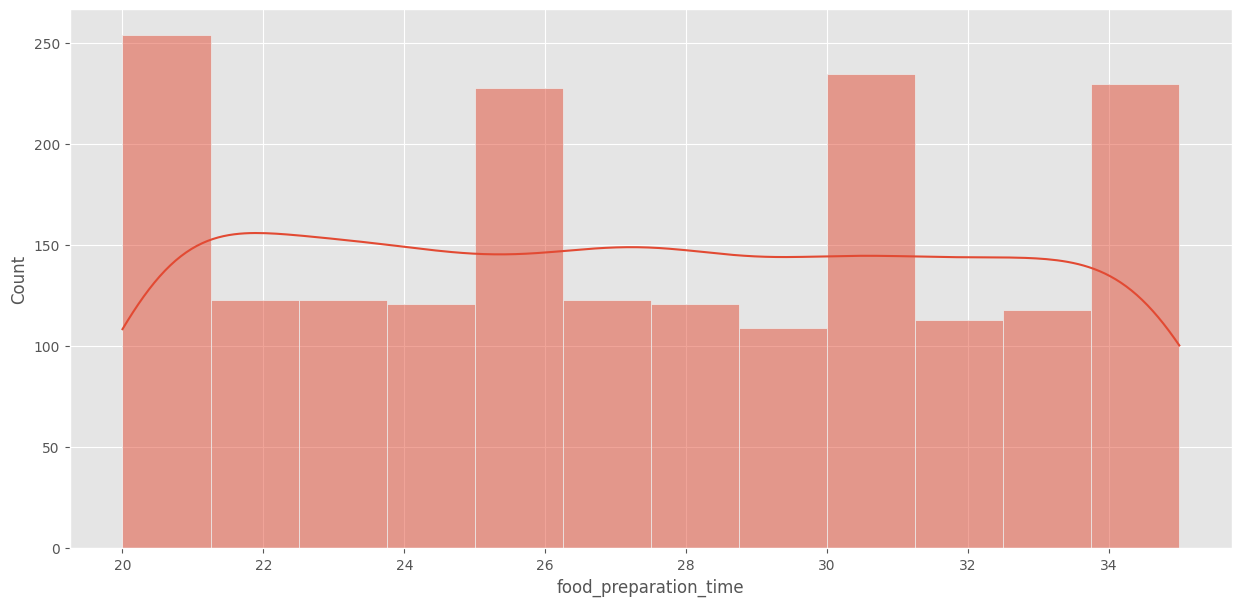

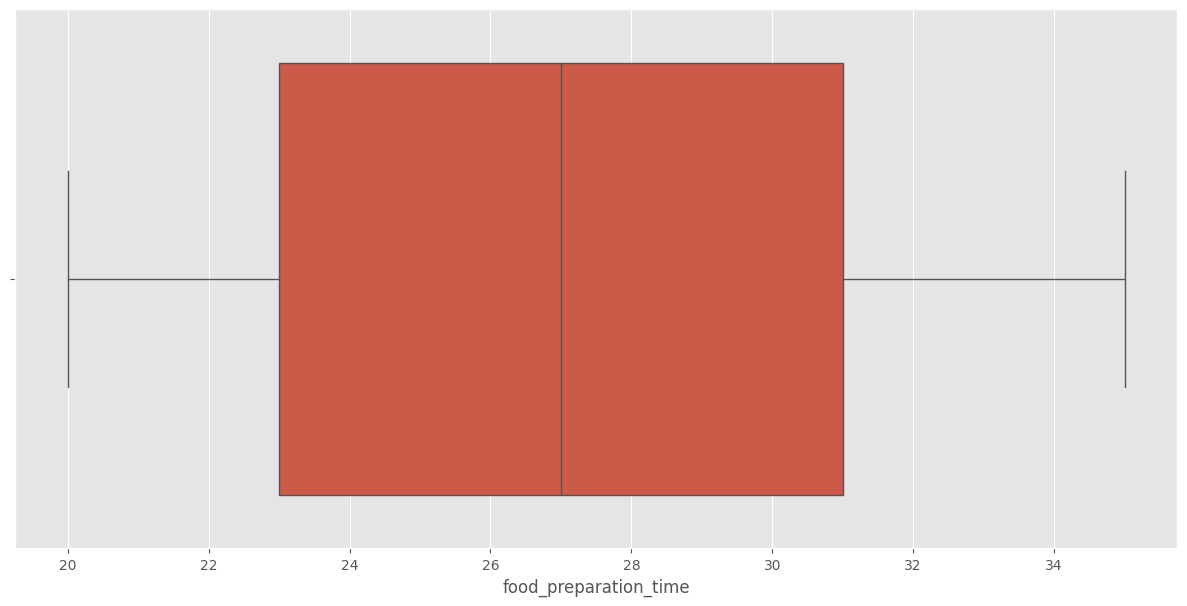

In [ ]:
#food_preparation_time
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ="food_preparation_time", kde = True)
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ="food_preparation_time")

<Axes: xlabel='delivery_time'>

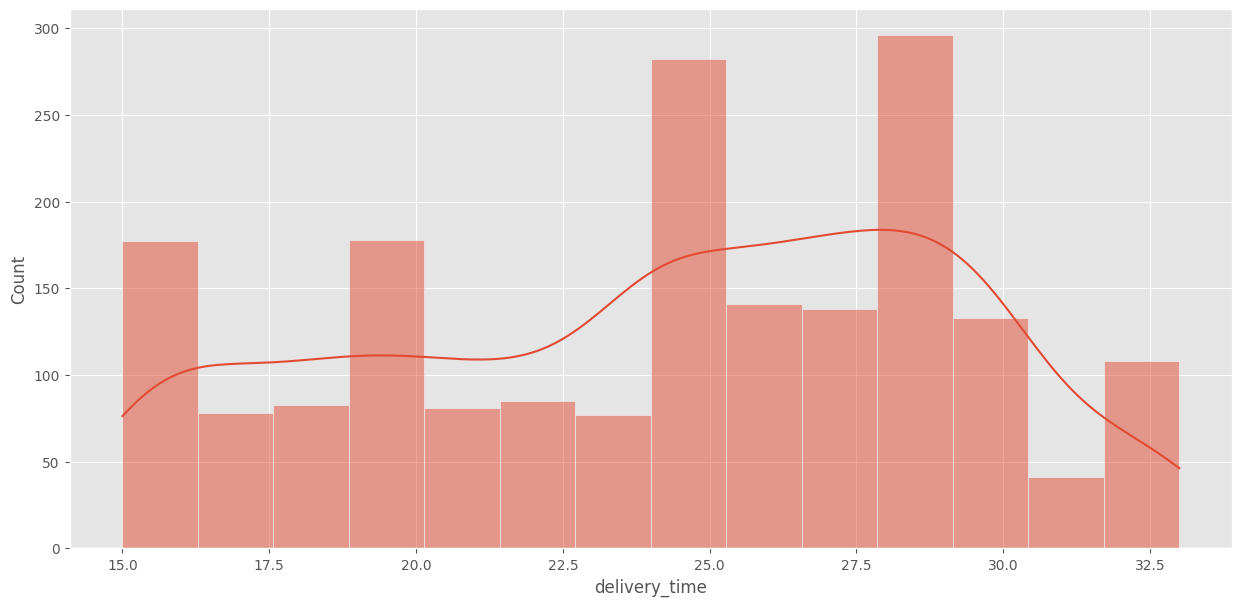

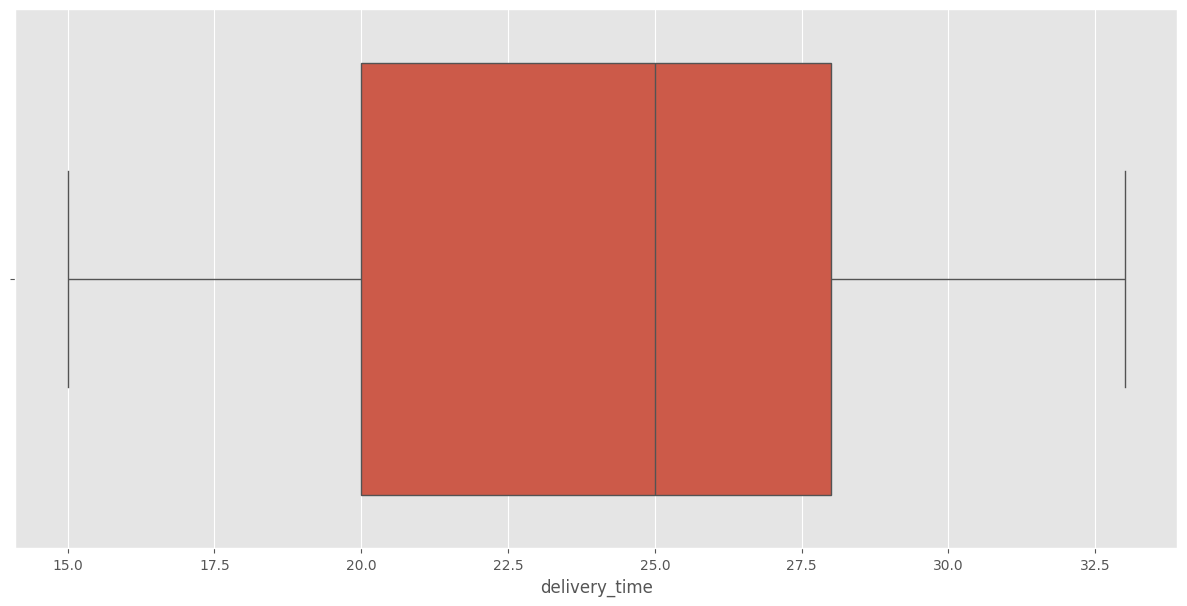

In [ ]:
#delivery_time
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ="delivery_time", kde = True)
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ="delivery_time")

**Observations:** The numerical columns for the df dataset are, "order_id", "customer_id", "cost_of_the_order", "food_preparation_time", and "delivery_time". The categorical columns for the df dataset are "cuisine_type", "rating" and "restaurant_name". See countplot for categorical columns and histplot and boxplot for numerical columns.

**order_id**

*   The countplot indicates, 5 order_id from the data set with a single order.

**customer_id**

*   The countplot indicates the top 5 most customer_id by number of orders.
*   Customer_id 52832 had the most orders at 13.

**restaurant_name**

*   The countplot indicates the top 5 restaurant_name most ordered from.
*   Shake Shack has the most orders with over 200.

**cuisine_type**

*   The countplot indicates the top 5 ordered cuisine_type.
*   American cuisine_type has the most orders with almost 600.
*   The histplot indicates all cuisine_type
*   The top 4 cuisine_type are between 200 and 600 orders. The remaining cuisine_type have under 100 orders.

**cost_of_the_order**

*   The histplot indicates that orders that were 12 dollars had the most occurrences and orders that were 28 or 35 dollars had the least occurrences.
*   The boxplot shows that the IQR are between 12 and 22 dollars and the median is 14 dollars. There are no outliers.

**rating**

*   The countplot indicates that there are more ratings "Not given" than given.
*   The histplot indicates that out of numerical ratings, there are more 5 ratings. There are no ratings of 1 or 2.

**food_preparation_time**

*   The countplot and the histplot indicate that the most frequent delivery time is 21 minutes and the least frequent delivery time is 29 minutes.
*   The boxplot shows that the IQR is between 21 and 31 minutes and the median is 25 minutes. There are no outliers.

**delivery_time**

*   The countplot indicates that most deliveries are made in 24 minutes.
*   However the histplot indicates that most deliveries are made between 28 and 29 minutes.
*   The boxplot shows that the IQR is between 20 and 28 minutes and the median is 25 minutes. There are no outliers.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df.value_counts('restaurant_name').head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


**Observations:** The top 5 resturants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicketn and Parm.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


**Observations:** The most popular cuisine ordered on the weekend is American.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
round(100*len(df[df['cost_of_the_order']>20])/len(df),2)

29.24

**Observations:** Out of the 1898 orders placed. 555 of them were over 20 dollars. Which is 29.24 percent.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
round(df['delivery_time'].mean(),2)

24.16

**Observations:** The mean of the delivery time is 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
df['customer_id'].value_counts().head()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


**Observations:** Based off of number of orders placed. The top 5 customers_ids are as follows...52832, 47440,83287, 250494 and 259341.

The most orders placed by one customer is 13.



### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [ ]:
num_var = ['cost_of_the_order','food_preparation_time','delivery_time']

<Axes: >

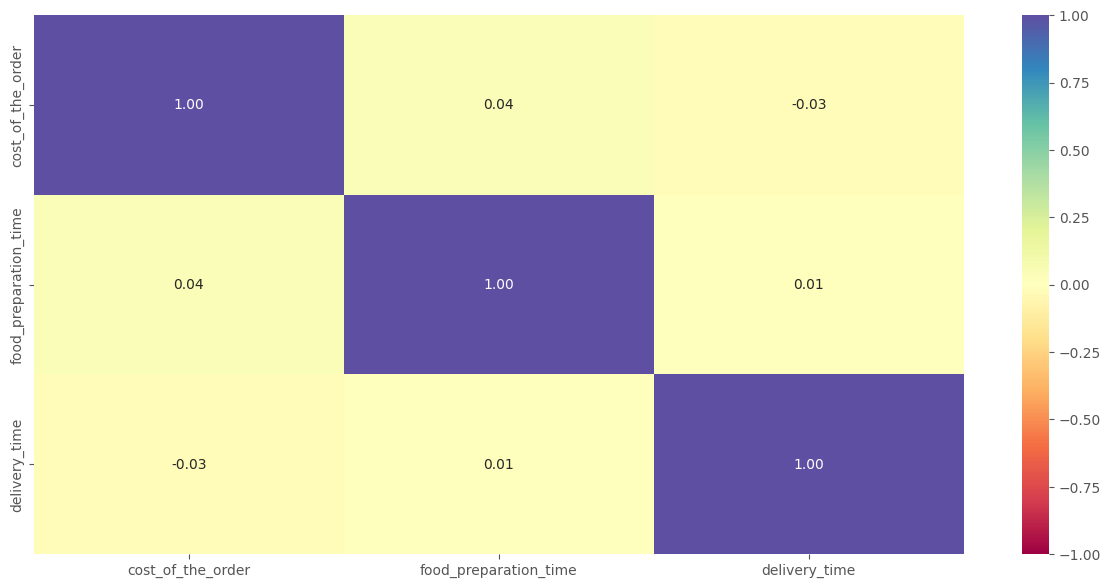

In [ ]:
plt.figure(figsize =(15,7))
sns.heatmap(data =df[num_var].corr(), annot =True,vmin =-1, vmax =1, fmt ='.2f', cmap ='Spectral')

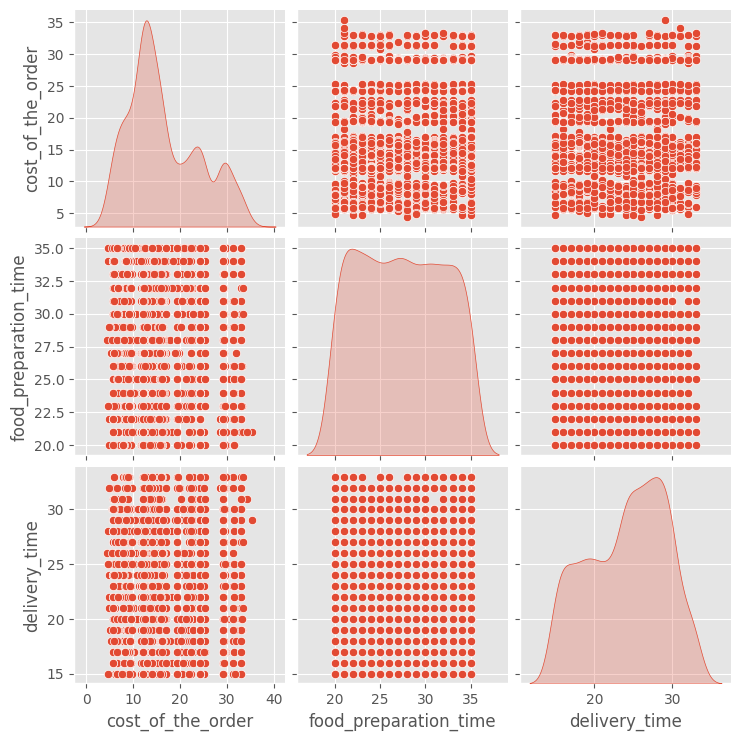

In [ ]:
sns.pairplot(data=df[num_var], diag_kind ='kde')

<Figure size 1500x700 with 0 Axes>

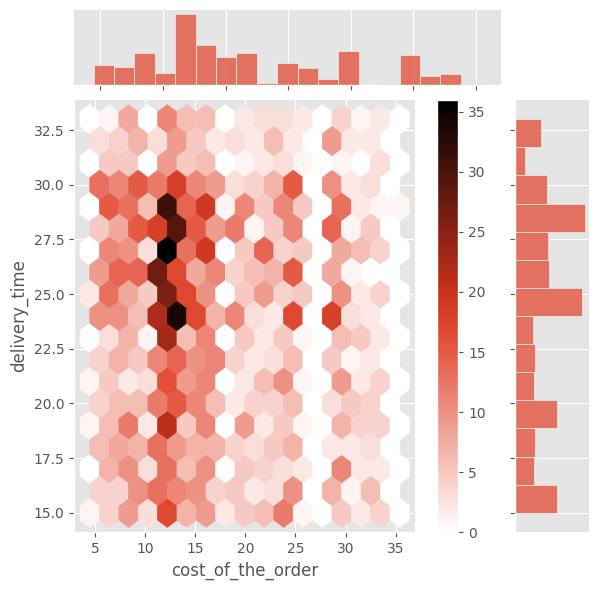

<Figure size 1500x700 with 0 Axes>

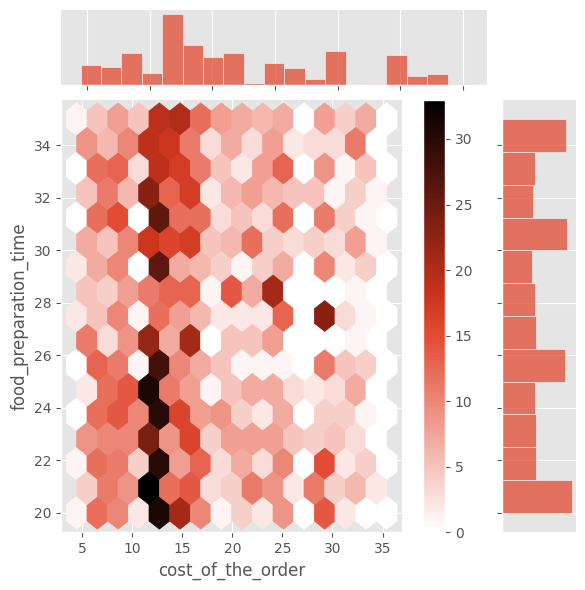

<Figure size 1500x700 with 0 Axes>

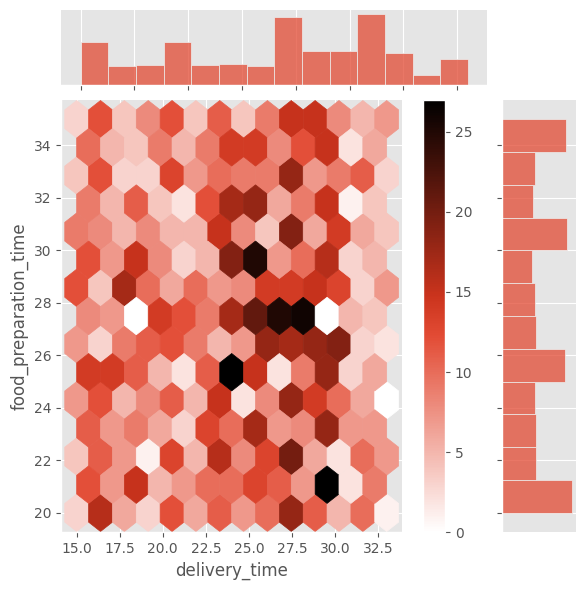

In [ ]:
plt.figure(figsize =(15,7))
sns.jointplot(data =df, x ='cost_of_the_order', y= 'delivery_time', kind ='hex');
plt.colorbar();
plt.figure(figsize =(15,7))
sns.jointplot(data =df, x ='cost_of_the_order', y= 'food_preparation_time', kind ='hex');
plt.colorbar();
plt.figure(figsize =(15,7))
sns.jointplot(data =df, x ='delivery_time', y= 'food_preparation_time', kind ='hex');
plt.colorbar();

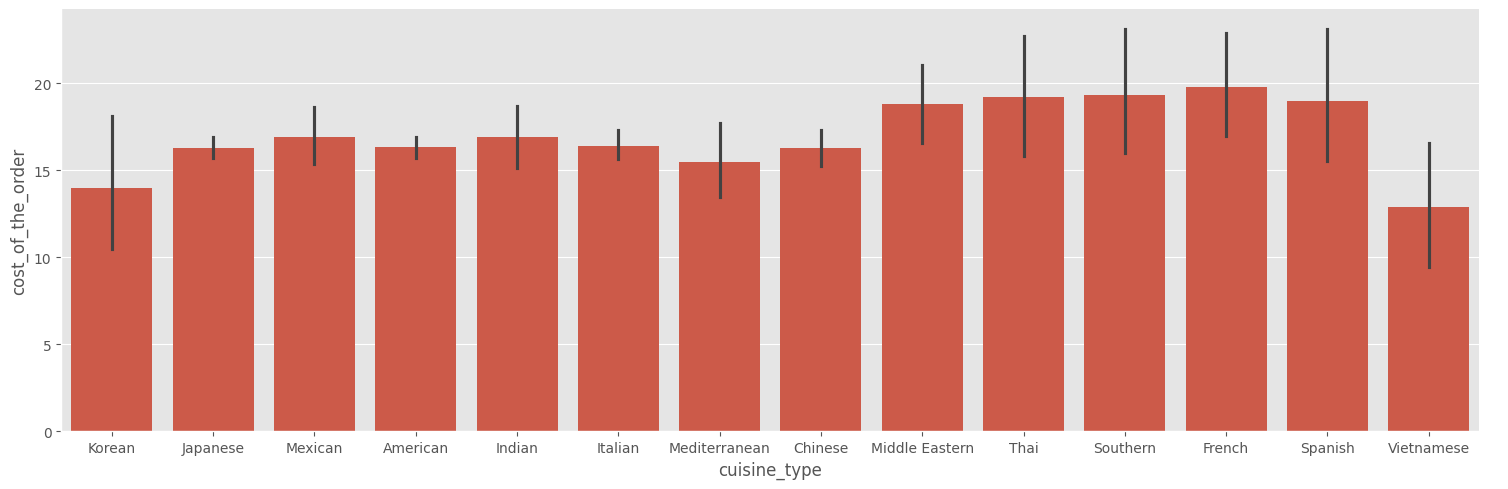

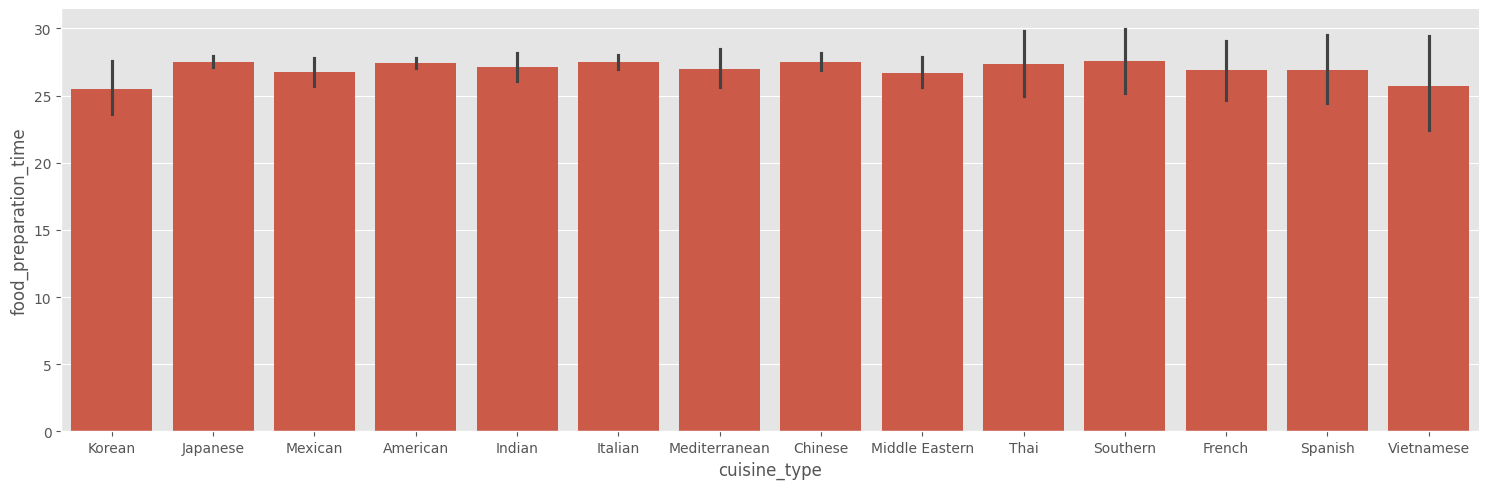

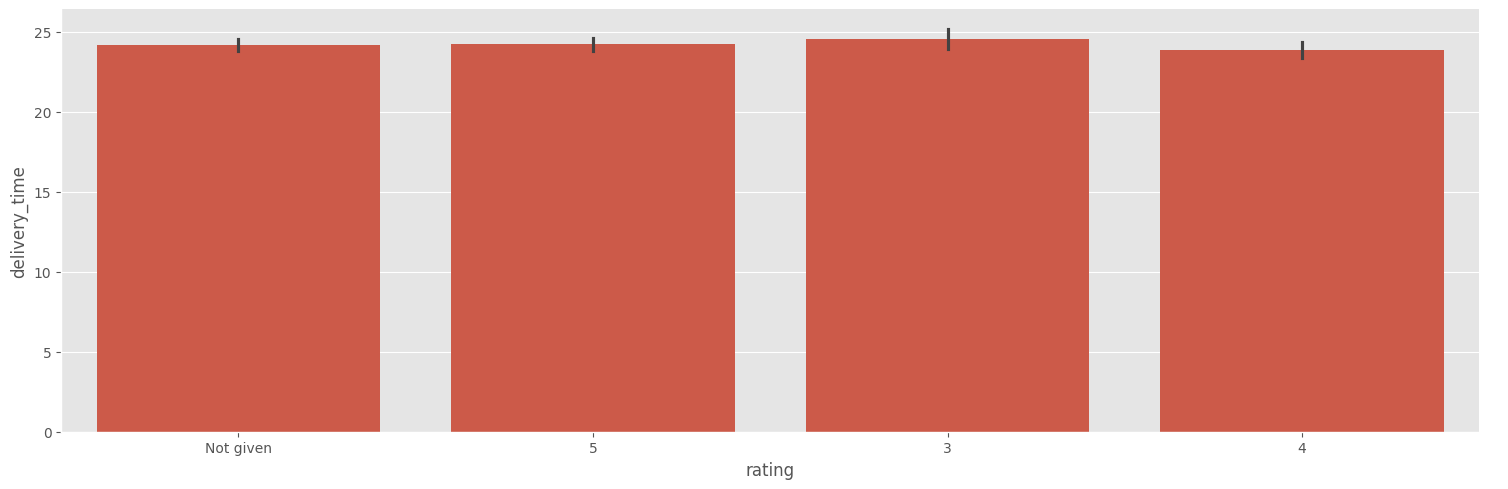

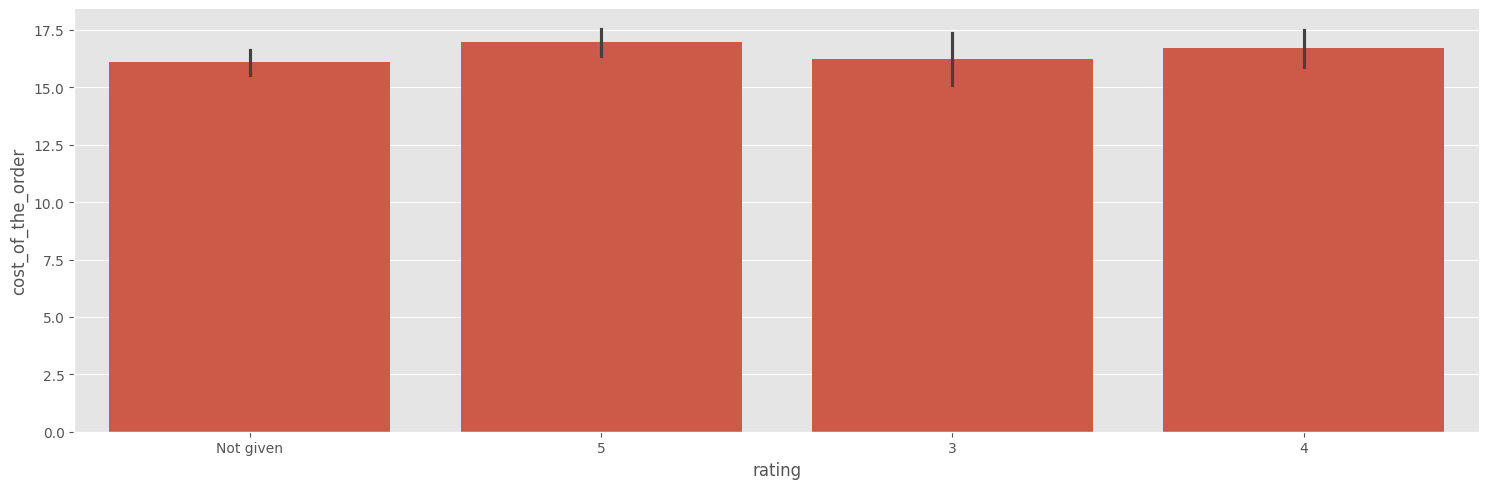

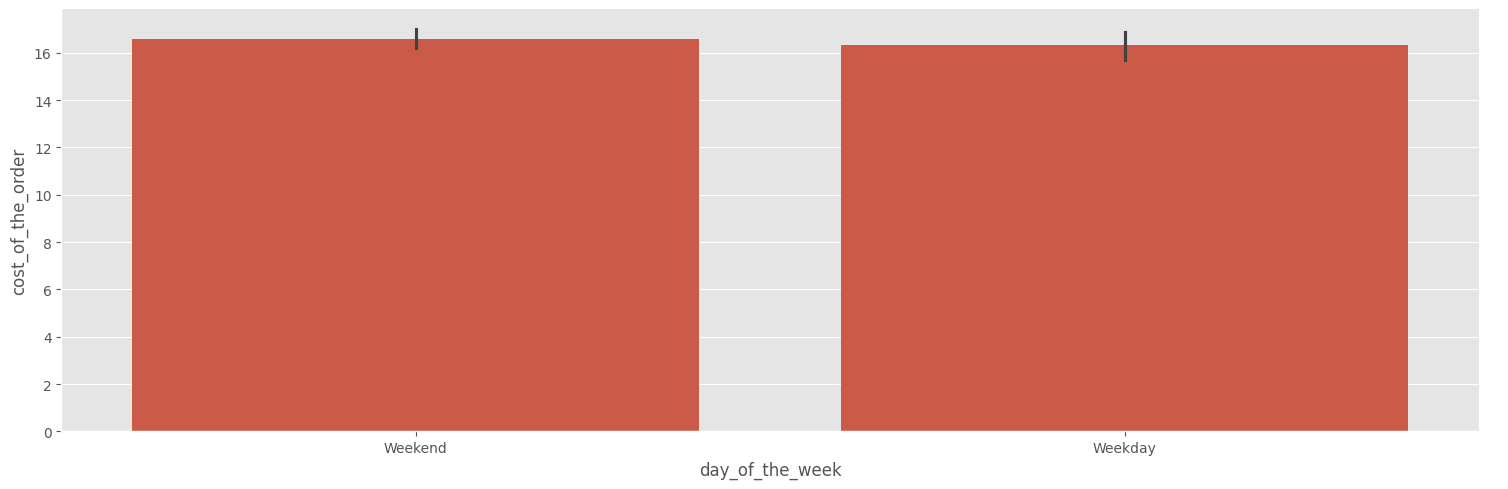

In [ ]:
sns.catplot(data =df, x ='cuisine_type',y ='cost_of_the_order', kind ='bar', height = 5, aspect =3)
sns.catplot(data =df, x ='cuisine_type',y ='food_preparation_time', kind ='bar', height = 5, aspect =3)
sns.catplot(data =df, x ='rating',y ='delivery_time', kind ='bar', height = 5, aspect =3)
sns.catplot(data =df, x ='rating',y ='cost_of_the_order', kind ='bar', height = 5, aspect =3)
sns.catplot(data =df, x ='day_of_the_week',y ='cost_of_the_order', kind ='bar', height = 5, aspect =3)

**Observation:**

**Heatmap**

**cost_of_the_order , food_preparation_time , delivery_time**

Between the three numerical columns (cost_of_the_order , food_preparation_time and delivery_time) there are no correlation between these columns. As they fall close to zero percent.

**Pairplot**

**cost_of_the_order , food_preparation_time , delivery_time**

Between the three numerical columns (cost_of_the_order , food_preparation_time and delivery_time) there are no correlation between these columns.

**Joinplot**

**cost_of_the_order & delivery_time**

*   35 or more orders falls in the 12/13 dollar range and 24 minute delivery time.
*   About 30 orders are close to 10 dollar range and 29 minute delivery time.

**cost_of_the_order & food_preparation_time**

*   Most orders (30+) fall in the 12/13 dollar range.
*   Most orders (30+) food preparation time are between 20 – 25 minutes.

**food_preparation_time & delivery_time**

*   Most orders (25+) are delivered in 27 to 31 minutes.
*   Most orders (25+) are prepared in 21 minutes.

**Catplot**

Multivariate analysis between numerical and categorical columns.

**cuisine_type and cost_of_the_order**

*   French cuisine and Southern cuisine are the most expensive.


**Food_prepration_time and cuisine_type**

*   All cuisine_type have a food_preparation_time of 25 minutes are more.

**Rating and Delivery_time**

*   All the ratings are close to 25 minutes in delivery time.
*   Rating “not given” is just about even with the 5 rating score.

**Cost_of_the_order and Rating**

*   Most 5 rated orders are about 17 dollars.
*   Most 4 rated orders are close to 17 dollars.

**Day_of_the_week and cost_of_the_order**

*   Weekend orders cost a little more (cents) than weekday orders.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
df['rating'].unique()
df_nan = df.replace(to_replace ="Not given", value =np.NaN)
df_nan['rating'] =df_nan['rating'].astype(dtype ='float')

In [ ]:
#in class code
rest_rating = df_nan.groupby('restaurant_name')['rating'].mean().reset_index()
rest_count = df_nan.groupby('restaurant_name')['rating'].count().reset_index()

In [ ]:
final_data = pd.merge(rest_rating,rest_count, how = 'inner', on='restaurant_name')

In [ ]:
final_data.rename(columns={'rating_x':'Avg_rating','rating_y':'Rating_count'},inplace = True)

In [ ]:
final_data[(final_data['Avg_rating']>4) & (final_data['Rating_count']>50)].sort_values(by = 'Avg_rating',ascending = False)

,restaurant_name,Avg_rating,Rating_count
153,The Meatball Shop,4.511905,84
20,Blue Ribbon Fried Chicken,4.328125,64
136,Shake Shack,4.278195,133
21,Blue Ribbon Sushi,4.219178,73


**Observations:**  

*   The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack and Blue Ribbon Sushi are the 4 restaurants that meet the criteria for the promotion.
*   They all have 50 or more ratings and an average rating above 4
*   Shake Shack has the most rating scores.
*   The Meatball Shop has the highest average rating score at 4.51.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
sum = 0

for i in df['cost_of_the_order']:
  if i >20:
    sum = sum+(i*0.25)
  elif( 5<i <20):
    sum = sum+(i*0.15)
  else:
    sum = sum+(i*0)

print('Revenue is $', round(sum,1))

Revenue is $ 6166.3


**Observations:** On this dataset FoodHub earned a revenue of 6,166.30 dollars.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
df['total_time'] = df['delivery_time'] + df['food_preparation_time']

In [ ]:
round(100*len(df[df['total_time']>60])/len(df),2)

10.54

**Observations:** Only 10.54 percnt of orders are delivered in more then 60 minutes.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
df.groupby(['day_of_the_week'])['delivery_time'].mean().reset_index()

,day_of_the_week,delivery_time
0,Weekday,28.340037
1,Weekend,22.470022


**Observations:** Orders place on the weekdays have an average delivery time of 28.34 minutes. Which is only 6 minutes more than the average delivery time on weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

**Conclusions:**

*   There are more missing customer feedback rating score, than rating scores received (148 more).
*   Shake Shack is the most popular restaurant that customers order from and they have an average rating of 4.2.
*  FoodHub has good delivery times. The average delivery time is 25 minutes. Only 10 percent of their order take over an hour to deliver.
*   American cuisine is the most popular cuisine order by customers.

**Recommendations:**

*  Encourage customers to provide feedback, especially if the customer is ordering frequently.
*   Continue to offer discounts to customers. Reward customers for providing feedback.
*   Continue to offer promotions to restaurants with high ratings. This will encourage them to produce quality service and they may encourage their customers to provide feedback as well.
*   Continue to have multiple American cuisine restaurants as it is the most ordered cuisine.

---